In [33]:
#This step focuses on understanding the problem, objects, constraints and expected outcomes
#Business Problem: Predict credit risk using financial features from the credit score dataset to identify individuals who are likely to default on loans
#Goal: Build a supervised classification model that accurately predicts whether a customer will default (1) or not default (0) based on their financial and demographic features. Use clustering to identify key useful variables.
#Usefulness: Enables banks and lending institutions to identify high-risk individuals, optimise credit allocation or reduce financial losses and improve overall decision-making transparency.
#Task type: Supervised learning for binary classification (default vs non-default)

Step 2 - Data understanding

In [34]:
#In this step, you explore the dataset, check structure, inspect missing values and gain initial insights

In [35]:
#Import libraries
#Import pandas for loading and exploring tabular data
import pandas as pd

#Import numpy for basic numerical operations
import numpy as np

#Import matplot for plotting
import matplotlib.pyplot as plt

#Import seaborn for statistical visualisations
import seaborn as sns

#Enable inline plotting so figures appear in the notebook
%matplotlib inline

In [36]:
#Load the credit score dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('credit_score.csv')

#Show the first 5 rows to get an initial look at the data
print("First 5 rows of the dataset:")
print(df.head())

#Display information about columns, data types and non-null counts
print("\nDescriptive statistics")
print(df.describe())

#Check for missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows of the dataset:
      CUST_ID  INCOME  SAVINGS     DEBT  R_SAVINGS_INCOME  R_DEBT_INCOME  \
0  C02COQEVYU   33269        0   532304            0.0000        16.0000   
1  C02OZKC0ZF   77158    91187   315648            1.1818         4.0909   
2  C03FHP2D0A   30917    21642   534864            0.7000        17.3000   
3  C03PVPPHOY   80657    64526   629125            0.8000         7.8000   
4  C04J69MUX0  149971  1172498  2399531            7.8182        16.0000   

   R_DEBT_SAVINGS  T_CLOTHING_12  T_CLOTHING_6  R_CLOTHING  ...  \
0          1.2000           1889           945      0.5003  ...   
1          3.4615           5818           111      0.0191  ...   
2         24.7142           1157           860      0.7433  ...   
3          9.7499           6857          3686      0.5376  ...   
4          2.0465           1978           322      0.1628  ...   

   R_EXPENDITURE_SAVINGS  R_EXPENDITURE_DEBT  CAT_GAMBLING  CAT_DEBT  \
0                 0.0000              0

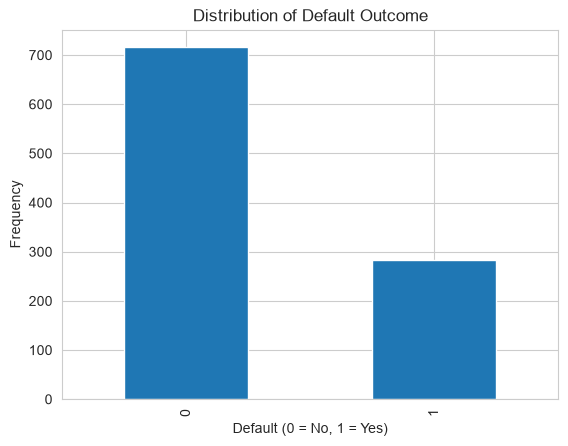

In [37]:
#Plot bar chart of target variable
df["DEFAULT"].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Frequency")
plt.title("Distribution of Default Outcome")
plt.show()

In [38]:
#Separating numerical and categorial data
#Numerical variables
numerical_features = [
    #financial variables
    'INCOME',
    'SAVINGS',
    'DEBT',
    'R_SAVINGS_INCOME',
    'R_DEBT_INCOME',
    'R_DEBT_SAVINGS',

    # Clothing
    'T_CLOTHING_6',
    'T_CLOTHING_12',
    'R_CLOTHING',
    'R_CLOTHING_INCOME',
    'R_CLOTHING_SAVINGS',
    'R_CLOTHING_DEBT',

    # Education
    'T_EDUCATION_12',
    'T_EDUCATION_6',
    'R_EDUCATION',
    'R_EDUCATION_INCOME',
    'R_EDUCATION_SAVINGS',
    'R_EDUCATION_DEBT',

    # Entertainment
    'T_ENTERTAINMENT_12',
    'T_ENTERTAINMENT_6',
    'R_ENTERTAINMENT',
    'R_ENTERTAINMENT_INCOME',
    'R_ENTERTAINMENT_SAVINGS',
    'R_ENTERTAINMENT_DEBT',

    # Fines
    'T_FINES_12',
    'T_FINES_6',
    'R_FINES',
    'R_FINES_INCOME',
    'R_FINES_SAVINGS',
    'R_FINES_DEBT',

    # Gambling
    'T_GAMBLING_12',
    'T_GAMBLING_6',
    'R_GAMBLING',
    'R_GAMBLING_INCOME',
    'R_GAMBLING_SAVINGS',
    'R_GAMBLING_DEBT',

    # Groceries
    'T_GROCERIES_12',
    'T_GROCERIES_6',
    'R_GROCERIES',
    'R_GROCERIES_INCOME',
    'R_GROCERIES_SAVINGS',
    'R_GROCERIES_DEBT',

    # Health
    'T_HEALTH_12',
    'T_HEALTH_6',
    'R_HEALTH',
    'R_HEALTH_INCOME',
    'R_HEALTH_SAVINGS',
    'R_HEALTH_DEBT',

    # Housing
    'T_HOUSING_12',
    'T_HOUSING_6',
    'R_HOUSING',
    'R_HOUSING_INCOME',
    'R_HOUSING_SAVINGS',
    'R_HOUSING_DEBT',

    # Tax
    'T_TAX_12',
    'T_TAX_6',
    'R_TAX',
    'R_TAX_INCOME',
    'R_TAX_SAVINGS',
    'R_TAX_DEBT',

    # Travel
    'T_TRAVEL_12',
    'T_TRAVEL_6',
    'R_TRAVEL',
    'R_TRAVEL_INCOME',
    'R_TRAVEL_SAVINGS',
    'R_TRAVEL_DEBT',

    # Utilities
    'T_UTILITIES_12',
    'T_UTILITIES_6',
    'R_UTILITIES',
    'R_UTILITIES_INCOME',
    'R_UTILITIES_SAVINGS',
    'R_UTILITIES_DEBT',

    # Total expenditure
    'T_EXPENDITURE_12',
    'T_EXPENDITURE_6',
    'R_EXPENDITURE',
    'R_EXPENDITURE_INCOME',
    'R_EXPENDITURE_SAVINGS',
    'R_EXPENDITURE_DEBT',

    #Credict score
    'CREDIT_SCORE'
]

#Categorical values
categorical_features = [
    'CAT_GAMBLING',
    'CAT_DEBT',
    'CAT_CREDIT_CARD',
    'CAT_MORTGAGE',
    'CAT_SAVINGS_ACCOUNT',
    'CAT_DEPENDENTS'
]

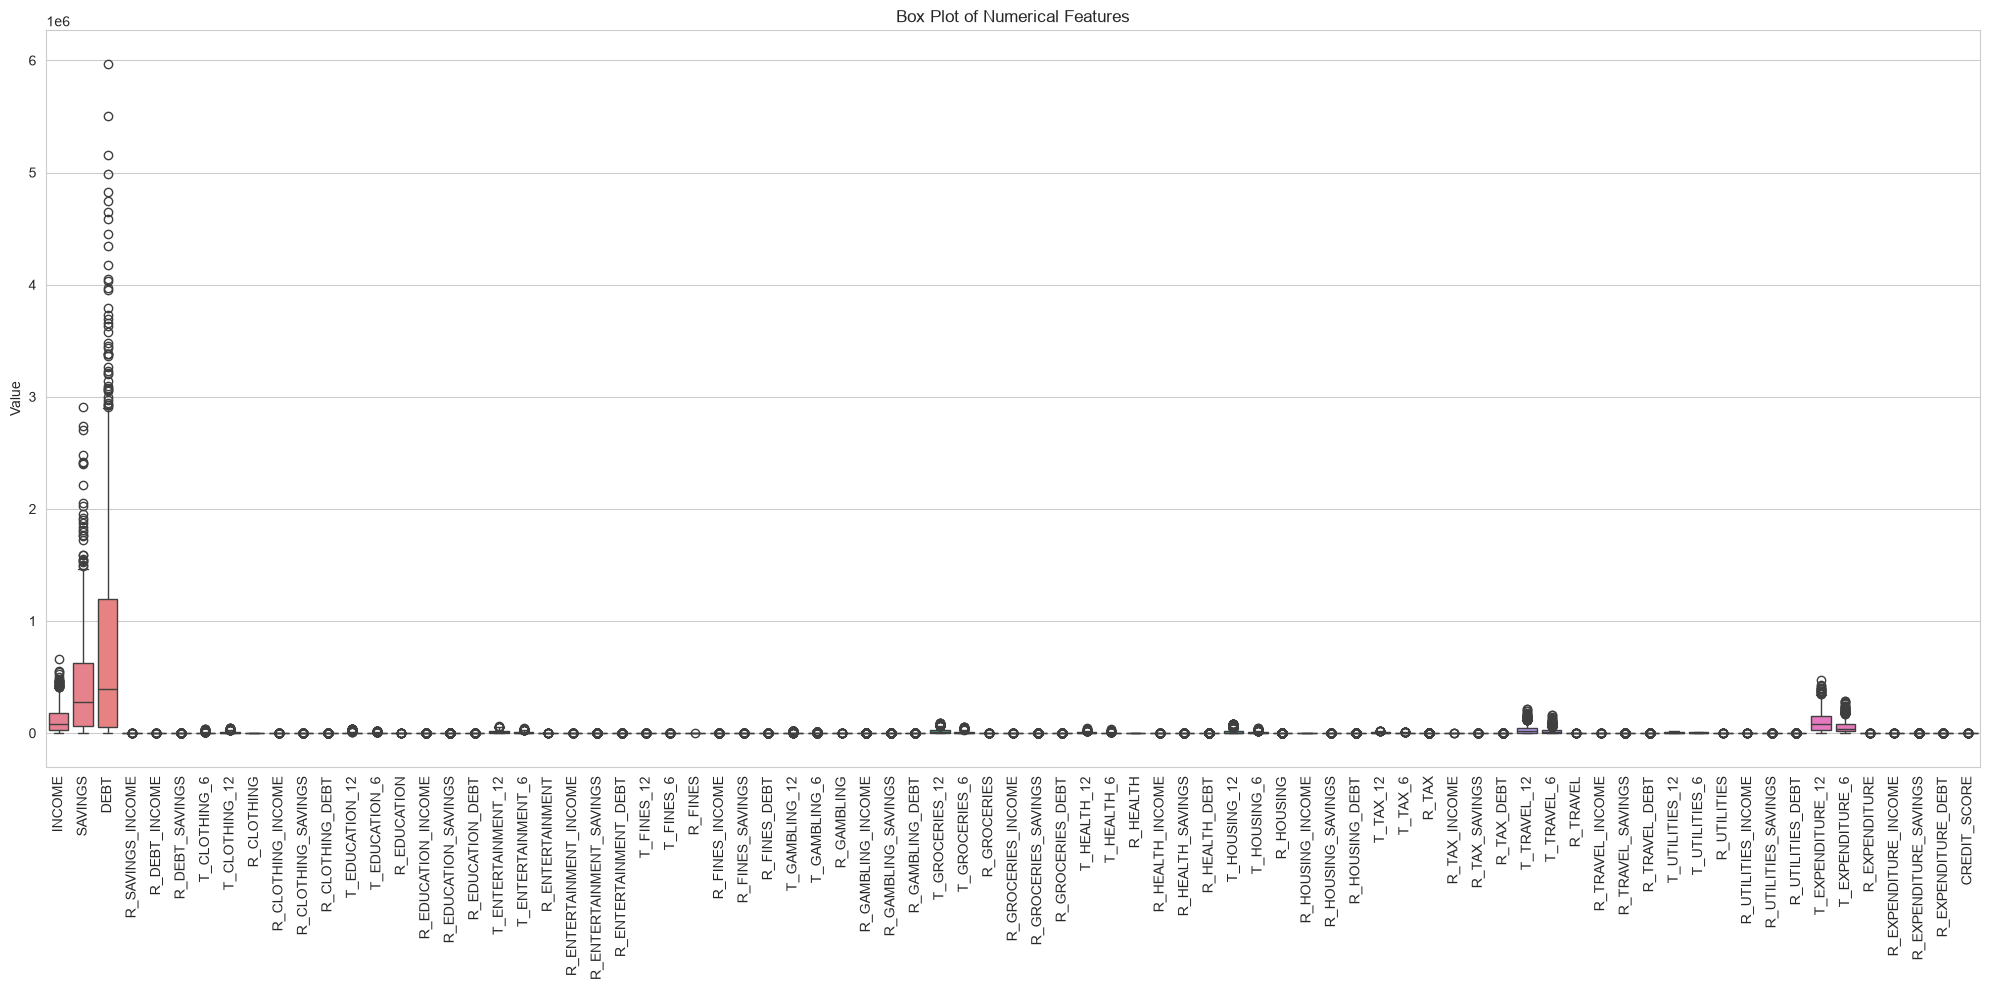

In [39]:
#Ploting box plots to see distribution of data and outliers
plt.figure(figsize=(20,10))
sns.boxplot(data=df[numerical_features])

plt.xticks(rotation=90)
plt.title("Box Plot of Numerical Features")
plt.ylabel('Value')

plt.tight_layout()
plt.show()

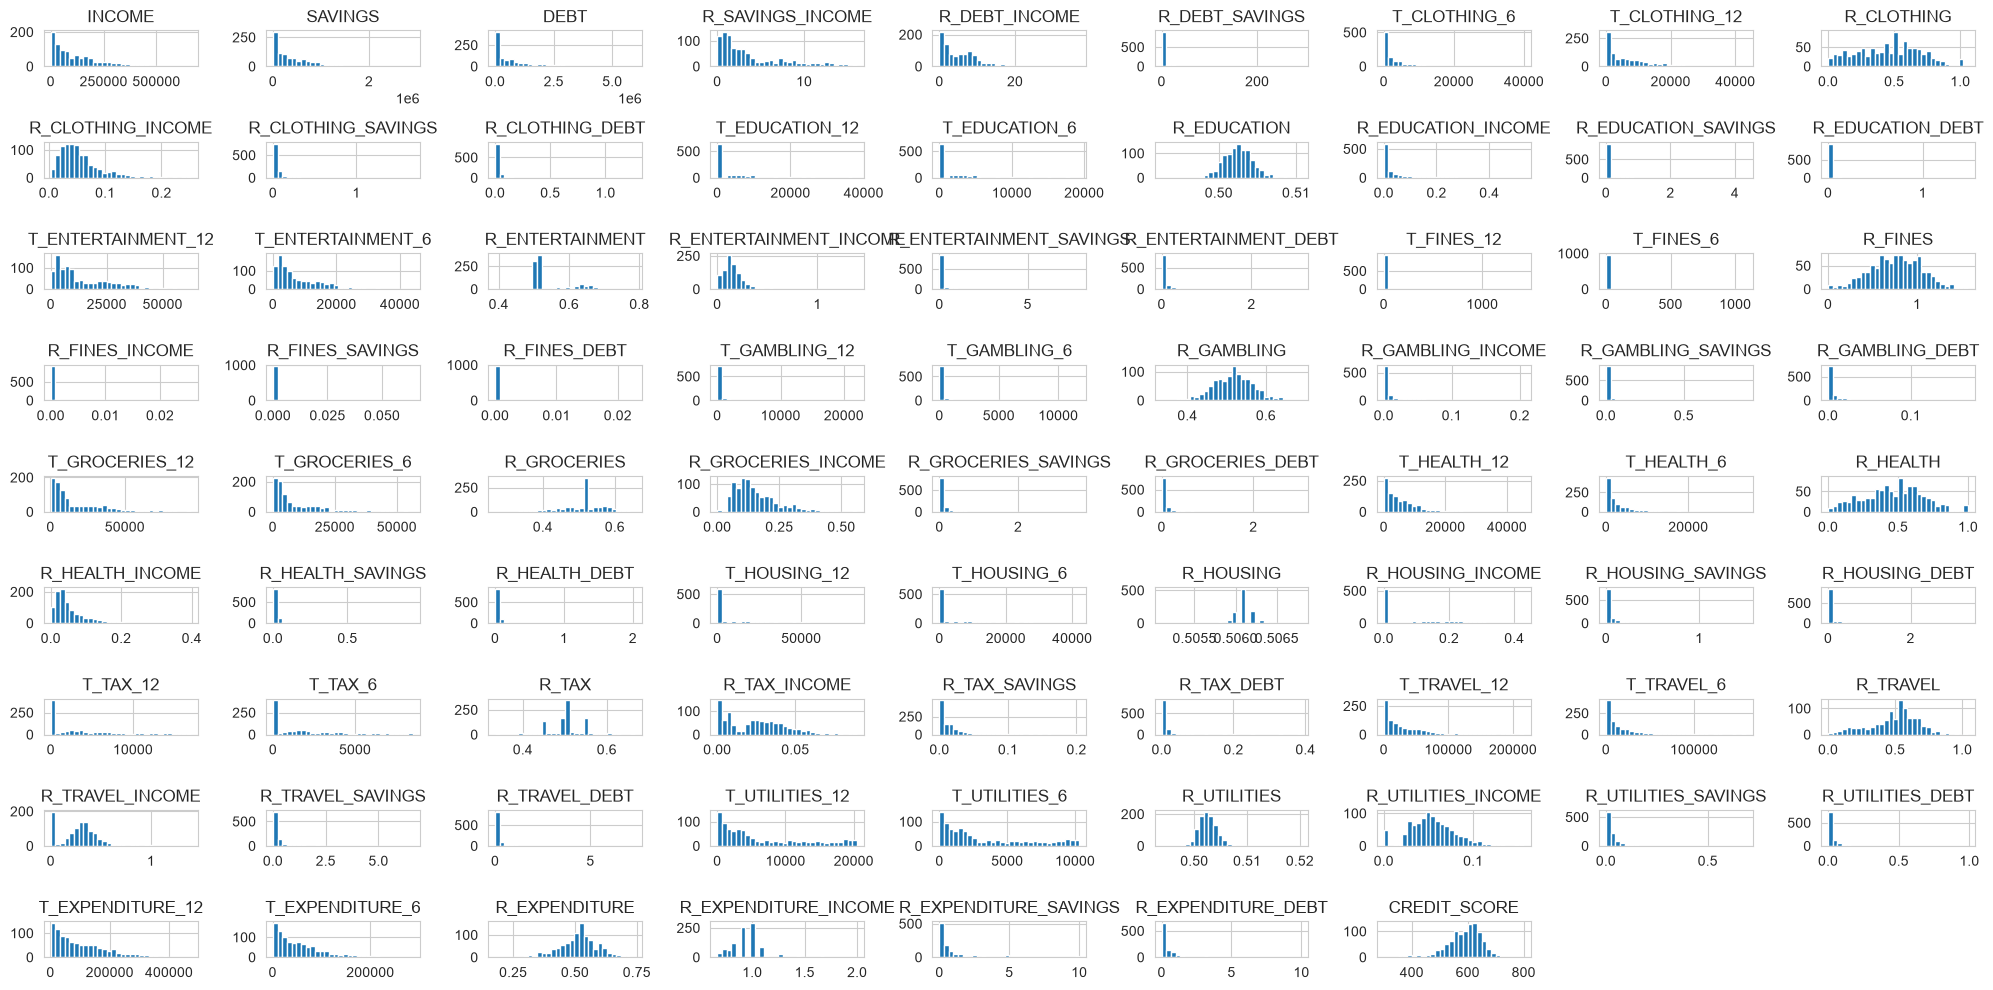

In [40]:
#Plotting histogram to see distribution
df[numerical_features].hist(
    figsize=(20,10),
    bins=30
)

plt.title("Distribution of Numerical Features,y=1.02")
plt.tight_layout()
plt.show()

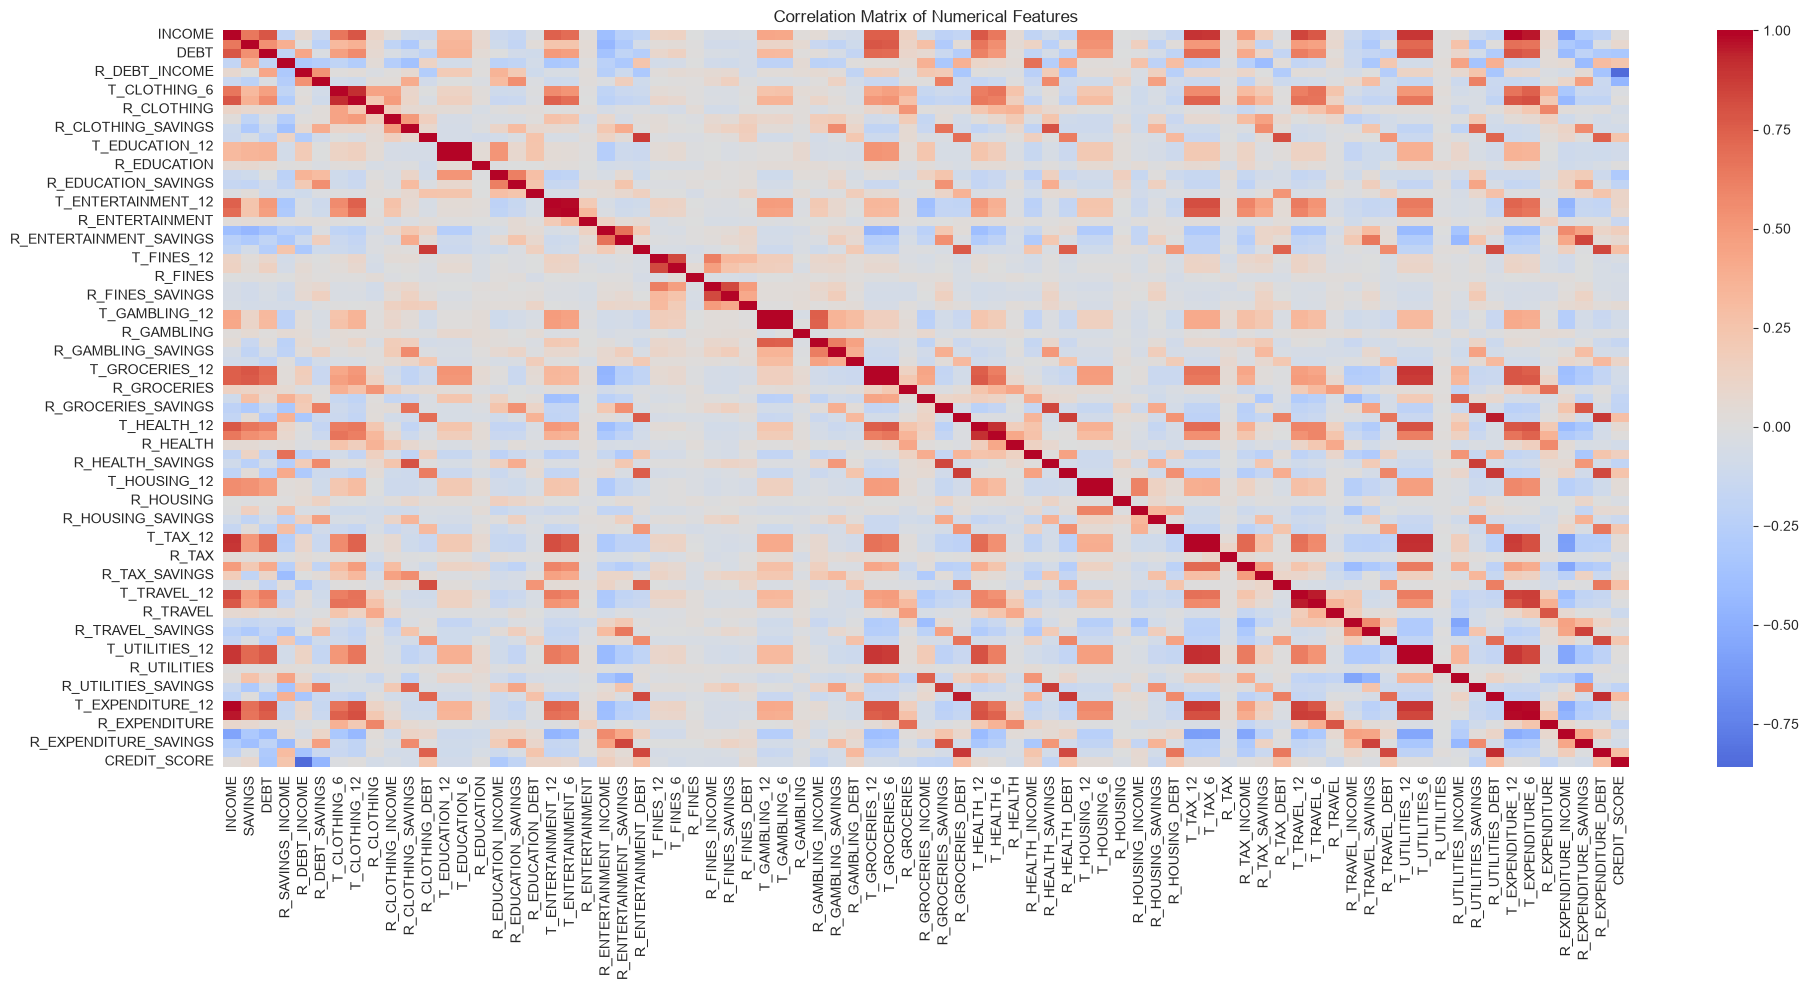

In [41]:
#Plotting correlation heatmap
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(20,10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [42]:
#Count unique variables
unique_values = df[numerical_features].nunique().sort_values()
print(unique_values.to_string())

R_HOUSING                   14
R_FINES_DEBT                24
R_FINES_SAVINGS             45
T_FINES_6                   48
R_FINES_INCOME              51
T_FINES_12                  71
R_EXPENDITURE_INCOME        72
R_UTILITIES                102
R_EDUCATION                102
R_EXPENDITURE_SAVINGS      210
R_GAMBLING_DEBT            228
R_EDUCATION_DEBT           234
R_TAX_DEBT                 253
R_GAMBLING_SAVINGS         257
R_TAX                      257
CREDIT_SCORE               259
R_EXPENDITURE_DEBT         280
R_GAMBLING_INCOME          304
R_EDUCATION_SAVINGS        324
R_TAX_SAVINGS              351
T_GAMBLING_6               361
R_EDUCATION_INCOME         365
T_EDUCATION_6              375
T_GAMBLING_12              377
T_EDUCATION_12             383
R_HOUSING_SAVINGS          392
R_HOUSING_DEBT             418
R_HEALTH_SAVINGS           425
R_TAX_INCOME               431
R_HOUSING_INCOME           440
R_HEALTH_DEBT              443
R_CLOTHING_DEBT            445
R_UTILIT

In [44]:
#Look at variance
variance = df[numerical_features].var().sort_values()
print(variance.to_string())

R_HOUSING                  1.330329e-08
R_FINES_DEBT               6.136601e-07
R_FINES_INCOME             1.933072e-06
R_UTILITIES                3.454595e-06
R_EDUCATION                3.648866e-06
R_FINES_SAVINGS            1.128088e-05
R_GAMBLING_DEBT            2.974426e-04
R_TAX_INCOME               3.648607e-04
R_TAX_SAVINGS              4.531162e-04
R_TAX_DEBT                 4.937650e-04
R_UTILITIES_INCOME         6.662749e-04
R_GAMBLING_INCOME          1.078650e-03
R_TAX                      1.368126e-03
R_CLOTHING_INCOME          1.411388e-03
R_HEALTH_SAVINGS           1.960848e-03
R_HEALTH_INCOME            2.042963e-03
R_GAMBLING                 2.730817e-03
R_UTILITIES_SAVINGS        2.789404e-03
R_GROCERIES                3.272191e-03
R_EDUCATION_DEBT           3.556181e-03
R_ENTERTAINMENT            3.916437e-03
R_GAMBLING_SAVINGS         4.024265e-03
R_EDUCATION_INCOME         5.481487e-03
R_EXPENDITURE              6.358461e-03
R_UTILITIES_DEBT           6.461038e-03
